# Prediction du Churn Client E-commerce — Modele a Risque Limite (AI Act)

**Risque limite** — Art. 50 | Obligations de transparence

## 0. Dependances optionnelles

In [1]:
# Author: Octo Technology MLOps Tribe
%pip install shap pandera --quiet

/Users/philippe.stepniewski/projets/model_platform/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [2]:
# Author: Octo Technology MLOps Tribe
import json
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import pandera as pa
from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
ARTIFACTS_DIR = Path(tempfile.mkdtemp())
print(f"Repertoire artefacts temporaires : {ARTIFACTS_DIR}")

Repertoire artefacts temporaires : /var/folders/k0/jqyr0y117r5gkrs84q5rb43c0000gn/T/tmph0yb8crq


## 2. Configuration MLflow

In [3]:
# Author: Octo Technology MLOps Tribe
PROJECT_NAME = "Ecommerce-Recommendation"
MLFLOW_TRACKING_URI = f"http://model-platform.com/registry/{PROJECT_NAME}/"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("customer_churn_prediction")
print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")

2026/03/20 16:11:31 INFO mlflow.tracking.fluent: Experiment with name 'customer_churn_prediction' does not exist. Creating a new experiment.


MLflow tracking URI : http://model-platform.com/registry/Ecommerce-Recommendation/


## 3. Generation des donnees synthetiques

In [4]:
# Author: Octo Technology MLOps Tribe
np.random.seed(42)
N = 7000

days_since_last_purchase = np.random.randint(0, 365, N)
num_purchases_90d        = np.random.poisson(lam=5, size=N).clip(0, 100)
avg_basket_value         = np.random.lognormal(mean=4.0, sigma=0.8, size=N).clip(5, 3000).round(2)
total_spend_12m          = np.random.lognormal(mean=6.5, sigma=1.0, size=N).clip(0, 50000).round(2)
num_returns_90d          = np.random.poisson(lam=1, size=N).clip(0, 20)
support_tickets_90d      = np.random.poisson(lam=0.5, size=N).clip(0, 10)
email_open_rate          = np.random.beta(3, 7, N).round(3)
session_frequency_30d    = np.random.exponential(scale=3, size=N).clip(0, 30).round(2)
loyalty_score            = np.random.uniform(0, 10, N).round(2)
nps_score                = np.random.randint(-10, 11, N)

log_odds = (
    -1.0
    + 0.008 * days_since_last_purchase
    - 0.05  * num_purchases_90d
    - 0.002 * total_spend_12m / 100
    + 0.1   * num_returns_90d
    + 0.2   * support_tickets_90d
    - 1.5   * email_open_rate
    - 0.08  * session_frequency_30d
    - 0.1   * loyalty_score
    - 0.05  * nps_score
)
prob_churn = 1 / (1 + np.exp(-log_odds))
will_churn = (np.random.rand(N) < prob_churn).astype(int)

FEATURES = [
    "days_since_last_purchase", "num_purchases_90d", "avg_basket_value",
    "total_spend_12m", "num_returns_90d", "support_tickets_90d",
    "email_open_rate", "session_frequency_30d", "loyalty_score", "nps_score",
]
TARGET = "will_churn"
PROTECTED_ATTRIBUTES = []

data_dict = {
    "days_since_last_purchase": days_since_last_purchase, "num_purchases_90d": num_purchases_90d,
    "avg_basket_value": avg_basket_value, "total_spend_12m": total_spend_12m,
    "num_returns_90d": num_returns_90d, "support_tickets_90d": support_tickets_90d,
    "email_open_rate": email_open_rate, "session_frequency_30d": session_frequency_30d,
    "loyalty_score": loyalty_score, "nps_score": nps_score, "will_churn": will_churn,
}

df = pd.DataFrame(data_dict)
print(f"Dataset : {len(df):,} lignes | Taux cible : {df[TARGET].mean():.1%}")

Dataset : 7,000 lignes | Taux cible : 33.0%


## 4. Validation Pandera & statistiques descriptives

In [5]:
# Author: Octo Technology MLOps Tribe
SCHEMA = pa.DataFrameSchema(
    name="customer_churn_input_schema",
    description="Contrat de donnees — Prediction du Churn Client E-commerce — Modele a Risque Limite (AI Act)",
    columns={
        "days_since_last_purchase": pa.Column(int,   checks=pa.Check.in_range(0, 365),    nullable=False, description="Jours depuis dernier achat"),
        "num_purchases_90d":        pa.Column(int,   checks=pa.Check.in_range(0, 200),    nullable=False, description="Achats sur 90 jours"),
        "avg_basket_value":         pa.Column(float, checks=pa.Check.in_range(0, 5000),   nullable=False, description="Valeur moyenne panier (EUR)"),
        "total_spend_12m":          pa.Column(float, checks=pa.Check.in_range(0, 100000), nullable=False, description="Depenses 12 mois (EUR)"),
        "num_returns_90d":          pa.Column(int,   checks=pa.Check.in_range(0, 50),     nullable=False, description="Retours sur 90 jours"),
        "support_tickets_90d":      pa.Column(int,   checks=pa.Check.in_range(0, 20),     nullable=False, description="Tickets support 90j"),
        "email_open_rate":          pa.Column(float, checks=pa.Check.in_range(0, 1),      nullable=False, description="Taux d'ouverture emails"),
        "session_frequency_30d":    pa.Column(float, checks=pa.Check.in_range(0, 50),     nullable=False, description="Sessions par semaine"),
        "loyalty_score":            pa.Column(float, checks=pa.Check.in_range(0, 10),     nullable=False, description="Score de fidelite (0-10)"),
        "nps_score":                pa.Column(int,   checks=pa.Check.in_range(-10, 10),   nullable=False, description="Score NPS"),
        "will_churn":               pa.Column(int,   checks=pa.Check.isin([0, 1]),         nullable=False, description="Cible : 1 = churn"),
    },
    coerce=False,
    strict=True,
)

try:
    SCHEMA.validate(df, lazy=True)
    PANDERA_STATUS = "PASS"
    PANDERA_ERRORS = 0
    print("Validation Pandera : SUCCES")
except pa.errors.SchemaErrors as exc:
    PANDERA_STATUS = "FAIL"
    PANDERA_ERRORS = len(exc.failure_cases)
    print(f"Validation Pandera : ECHEC ({PANDERA_ERRORS} erreurs)")

Validation Pandera : SUCCES


In [6]:
# Author: Octo Technology MLOps Tribe
print("=== Statistiques descriptives ===")
display(df[FEATURES + [TARGET]].describe().round(3))

print("\n=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "Aucune valeur manquante.")

print(f"\n=== Distribution de la variable cible ===")
vc = df[TARGET].value_counts().sort_index()
for k, v in vc.items():
    print(f"  Classe {k} : {v:,} ({v/len(df):.1%})")

=== Statistiques descriptives ===


,days_since_last_purchase,num_purchases_90d,avg_basket_value,total_spend_12m,num_returns_90d,support_tickets_90d,email_open_rate,session_frequency_30d,loyalty_score,nps_score,will_churn
count,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.00
mean,181.349,5.007,75.396,1080.616,1.006,0.503,0.305,2.922,5.040,0.001,0.33
std,105.104,2.226,69.307,1324.312,0.999,0.707,0.137,2.981,2.907,6.101,0.47
min,0.000,0.000,5.000,24.820,0.000,0.000,0.011,0.000,0.000,-10.000,0.00
25%,93.000,3.000,31.810,345.653,0.000,0.000,0.201,0.840,2.520,-5.000,0.00
50%,180.000,5.000,55.175,670.020,1.000,0.000,0.294,2.010,5.040,0.000,0.00
75%,273.000,6.000,95.180,1292.182,2.000,1.000,0.399,4.020,7.572,5.000,1.00
max,364.000,15.000,924.470,19967.790,7.000,5.000,0.844,28.350,10.000,10.000,1.00



=== Valeurs manquantes ===
Aucune valeur manquante.

=== Distribution de la variable cible ===
  Classe 0 : 4,690 (67.0%)
  Classe 1 : 2,310 (33.0%)


In [7]:
# Author: Octo Technology MLOps Tribe
SCHEMA_YAML_EXPORTED = False
try:
    schema_yaml_path = ARTIFACTS_DIR / "pandera_schema.yaml"
    with open(schema_yaml_path, "w") as f:
        f.write(SCHEMA.to_yaml())
    SCHEMA_YAML_EXPORTED = True
    print("Schema Pandera exporte -> pandera_schema.yaml")
except Exception as e:
    print(f"Export YAML non disponible : {e}")

validation_report = {
    "schema_name": SCHEMA.name,
    "validation_status": PANDERA_STATUS,
    "validation_errors": PANDERA_ERRORS,
    "n_rows_validated": int(len(df)),
    "protected_attributes": PROTECTED_ATTRIBUTES,
}
validation_report_path = ARTIFACTS_DIR / "data_validation_report.json"
with open(validation_report_path, "w") as f:
    json.dump(validation_report, f, indent=2, ensure_ascii=False)
print("Rapport de validation exporte -> data_validation_report.json")

Schema Pandera exporte -> pandera_schema.yaml
Rapport de validation exporte -> data_validation_report.json


## 5. Pretraitement

In [8]:
# Author: Octo Technology MLOps Tribe
X, y = df[FEATURES], df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print(f"Train : {len(X_train):,}  |  Validation : {len(X_val):,}  |  Test : {len(X_test):,}")
print(f"Taux cible — train : {y_train.mean():.1%}  |  test : {y_test.mean():.1%}")

Train : 4,760  |  Validation : 840  |  Test : 1,400
Taux cible — train : 33.0%  |  test : 33.0%


## 6. Entrainement du modele

In [9]:
# Author: Octo Technology MLOps Tribe
PARAMS = {
    "n_estimators":  200,
    "max_depth":     8,
    "class_weight":  "balanced",
    "random_state":  42,
    "n_jobs":        -1,
}

model = RandomForestClassifier(**PARAMS)
model.fit(X_train_sc, y_train)

val_proba = model.predict_proba(X_val_sc)
if 2 == 2:
    val_auc = roc_auc_score(y_val, val_proba[:, 1])
else:
    val_auc = roc_auc_score(y_val, val_proba, multi_class="ovr", average="macro")
print(f"AUC-ROC validation : {val_auc:.4f}")
print("Entrainement termine.")

AUC-ROC validation : 0.7136
Entrainement termine.


## 7. Evaluation sur le jeu de test

In [10]:
# Author: Octo Technology MLOps Tribe
y_pred  = model.predict(X_test_sc)
y_proba_all = model.predict_proba(X_test_sc)
if 2 == 2:
    y_proba = y_proba_all[:, 1]
    auc_val = round(float(roc_auc_score(y_test, y_proba)), 4)
else:
    y_proba = y_proba_all
    auc_val = round(float(roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")), 4)

METRICS = {
    "accuracy":  round(float(accuracy_score(y_test, y_pred)),  4),
    "precision": round(float(precision_score(y_test, y_pred, average="weighted", zero_division=0)), 4),
    "recall":    round(float(recall_score(y_test, y_pred,    average="weighted", zero_division=0)), 4),
    "f1_score":  round(float(f1_score(y_test, y_pred,        average="weighted", zero_division=0)), 4),
    "auc_roc":   auc_val,
}

report_dict = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))
print("\n".join(f"{k:<12}: {v}" for k, v in METRICS.items()))

              precision    recall  f1-score   support

           0       0.80      0.73      0.76       938
           1       0.53      0.63      0.58       462

    accuracy                           0.70      1400
   macro avg       0.67      0.68      0.67      1400
weighted avg       0.71      0.70      0.70      1400

accuracy    : 0.6971
precision   : 0.7131
recall      : 0.6971
f1_score    : 0.7027
auc_roc     : 0.7436


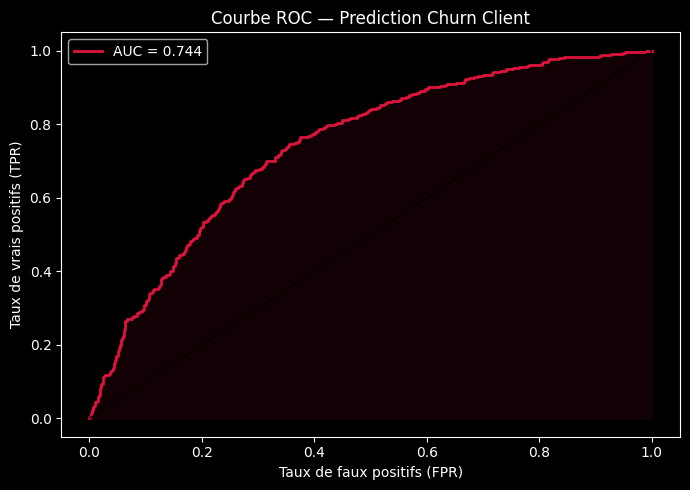

In [11]:
# Author: Octo Technology MLOps Tribe
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
if 2 == 2:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="crimson", lw=2, label=f"AUC = {METRICS['auc_roc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color="crimson")
    ax.set_xlabel("Taux de faux positifs (FPR)")
    ax.set_ylabel("Taux de vrais positifs (TPR)")
    ax.set_title("Courbe ROC — Prediction Churn Client")
    ax.legend()
else:
    class_names = ["Classe 0", "Classe 1"]
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title("Courbe ROC — Prediction Churn Client")
plt.tight_layout()
roc_path = ARTIFACTS_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150)
plt.show()

## 8. Analyse d'equite (Fairness)

In [12]:
# Author: Octo Technology MLOps Tribe
df_eval = X_test.copy()
df_eval["target"]    = y_test.values
df_eval["predicted"] = y_pred
if 2 == 2:
    df_eval["proba"] = y_proba
else:
    for _i in range(2):
        df_eval[f"proba_{_i}"] = y_proba[:, _i]

def subgroup_metrics(group):
    if len(group) < 20:
        return None
    try:
        if 2 == 2:
            auc = round(float(roc_auc_score(group["target"], group["proba"])), 4) if group["target"].nunique() > 1 else "N/A"
        else:
            proba_cols = [f"proba_{_i}" for _i in range(2)]
            auc = round(float(roc_auc_score(group["target"], group[proba_cols].values, multi_class="ovr", average="macro")), 4) if group["target"].nunique() > 1 else "N/A"
    except Exception:
        auc = "N/A"
    return {
        "n":         int(len(group)),
        "target_rate": round(float(group["target"].mean()), 4),
        "accuracy":  round(float(accuracy_score(group["target"], group["predicted"])), 4),
        "recall":    round(float(recall_score(group["target"], group["predicted"], average="weighted", zero_division=0)), 4),
        "precision": round(float(precision_score(group["target"], group["predicted"], average="weighted", zero_division=0)), 4),
        "auc_roc":   auc,
    }

# Pas d'attribut protege — analyse par segment de fidelite
loyalty_bins = pd.cut(df_eval["loyalty_score"], bins=[0, 3, 7, 10], labels=["Faible", "Moyen", "Eleve"])
fairness_by_loyalty = {str(k): subgroup_metrics(v) for k, v in df_eval.groupby(loyalty_bins, observed=True)}
print("=== Performance par segment de fidelite ===")
print(pd.DataFrame(fairness_by_loyalty).T.to_string())

FAIRNESS_REPORT = {
    "protected_attributes": [],
    "note": "Aucun attribut protege — analyse de la performance par segment de fidelite.",
    "by_loyalty_segment": fairness_by_loyalty,
}

fairness_path = ARTIFACTS_DIR / "fairness_report.json"
with open(fairness_path, "w") as f:
    json.dump(FAIRNESS_REPORT, f, indent=2, ensure_ascii=False)
print("Rapport d'equite exporte.")

=== Performance par segment de fidelite ===
            n  target_rate  accuracy  recall  precision  auc_roc
Faible  403.0       0.3921    0.6824  0.6824     0.6911   0.7327
Moyen   548.0       0.3394    0.6661  0.6661     0.6820   0.7188
Eleve   448.0       0.2634    0.7478  0.7478     0.7717   0.7727
Rapport d'equite exporte.


## 9. Explicabilite

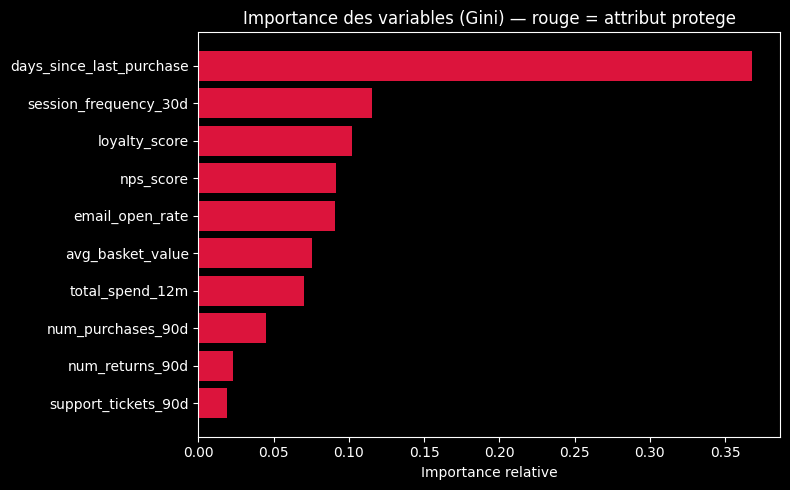

                 feature  importance
days_since_last_purchase    0.368085
   session_frequency_30d    0.115326
           loyalty_score    0.101783
               nps_score    0.091211
         email_open_rate    0.091002
        avg_basket_value    0.075698
         total_spend_12m    0.070436
       num_purchases_90d    0.044748
         num_returns_90d    0.022844
     support_tickets_90d    0.018867


In [13]:
# Author: Octo Technology MLOps Tribe
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    imp_label = "Importance des variables (Gini)"
elif hasattr(model, "coef_"):
    coef = model.coef_
    importances = np.abs(coef).mean(axis=0) if coef.ndim > 1 else np.abs(coef[0])
    imp_label = "Importance des variables (|coef| moyen)"
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#c0392b" if f in PROTECTED_ATTRIBUTES else "crimson" for f in fi_df["feature"][::-1]]
    ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color=colors)
    ax.set_title(f"{imp_label} — rouge = attribut protege")
    ax.set_xlabel("Importance relative")
    plt.tight_layout()
    fi_path = ARTIFACTS_DIR / "feature_importance.png"
    plt.savefig(fi_path, dpi=150)
    plt.show()
    print(fi_df.to_string(index=False))
else:
    fi_df = None
    print("Aucune methode d'importance disponible pour ce modele.")

In [14]:
# Author: Octo Technology MLOps Tribe
SHAP_AVAILABLE = False
try:
    import shap
    if hasattr(model, "feature_importances_"):
        explainer = shap.TreeExplainer(model)
    else:
        explainer = shap.Explainer(model, X_train_sc)
    shap_values = explainer.shap_values(X_test_sc.iloc[:300])
    plt.figure()
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_test_sc.iloc[:300], show=False, plot_size=(10, 6))
    shap_path = ARTIFACTS_DIR / "shap_summary.png"
    plt.savefig(shap_path, dpi=150, bbox_inches="tight")
    plt.close()
    SHAP_AVAILABLE = True
    print("SHAP summary plot genere.")
except ImportError:
    print("SHAP non disponible — installer avec : pip install shap")
except Exception as e:
    print(f"SHAP non disponible pour ce modele : {e}")

SHAP non disponible — installer avec : pip install shap


## 10. Preparation des artefacts de documentation

In [15]:
# Author: Octo Technology MLOps Tribe
cr_path = ARTIFACTS_DIR / "classification_report.json"
with open(cr_path, "w") as f:
    json.dump(report_dict, f, indent=2, ensure_ascii=False)

fi_csv_path = ARTIFACTS_DIR / "feature_importance.csv"
fi_df.to_csv(fi_csv_path, index=False)

pp_context = {"schema_name": SCHEMA.name, "pandera_status": PANDERA_STATUS, "pandera_errors": PANDERA_ERRORS}
preprocessing_md = Path("preprocessing_description_churn_template.md").read_text(encoding="utf-8").format_map(pp_context)
pp_path = ARTIFACTS_DIR / "preprocessing_description.md"
pp_path.write_text(preprocessing_md, encoding="utf-8")

print("Artefacts prepares :")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}")

Artefacts prepares :
  classification_report.json
  data_validation_report.json
  fairness_report.json
  feature_importance.csv
  feature_importance.png
  pandera_schema.yaml
  preprocessing_description.md
  roc_curve.png


## 11. Logging MLflow

In [16]:
# Author: Octo Technology MLOps Tribe
MODEL_NAME  = "customer_churn_predictor"
TEAM        = "mlops-tribe"
ENVIRONMENT = "staging"

model_card_text = Path("model_card_churn.md").read_text(encoding="utf-8")
model_card_path = ARTIFACTS_DIR / "model_card.md"
model_card_path.write_text(model_card_text, encoding="utf-8")

with mlflow.start_run(run_name=f"{MODEL_NAME}_v1") as run:
    mlflow.log_params(PARAMS)
    mlflow.log_param("scaler",           "StandardScaler")
    mlflow.log_param("feature_count",    len(FEATURES))
    mlflow.log_param("features",         ", ".join(FEATURES))
    mlflow.log_param("stratified_split", True)
    mlflow.log_param("train_size",       len(X_train))
    mlflow.log_param("val_size",         len(X_val))
    mlflow.log_param("test_size",        len(X_test))

    mlflow.log_metrics(METRICS)
    mlflow.log_metric("auc_roc_validation", round(val_auc, 4))
    mlflow.log_metric("target_rate_train",  round(float(y_train.mean()), 4))
    mlflow.log_metric("target_rate_test",   round(float(y_test.mean()), 4))
    mlflow.log_metric("dataset_total_size", N)

    mlflow.set_tag("model_type",             "RandomForestClassifier")
    mlflow.set_tag("framework",              "scikit-learn")
    mlflow.set_tag("data_source",            "Donnees synthetiques e-commerce")
    mlflow.set_tag("contains_personal_data", "non — donnees comportementales agreges")
    mlflow.set_tag("protected_attributes",   "aucun")
    mlflow.set_tag("threshold_accuracy",     "0.80")
    mlflow.set_tag("threshold_f1",           "0.70")
    mlflow.set_tag("threshold_auc_roc",      "0.87")
    mlflow.set_tag("threshold_recall",       "0.70")

    mlflow.set_tag("model.author",      "Octo Technology MLOps Tribe")
    mlflow.set_tag("model.team",        TEAM)
    mlflow.set_tag("model.environment", ENVIRONMENT)
    mlflow.set_tag("data.synthetic",    "true")
    mlflow.set_tag("pandera.status",    PANDERA_STATUS)
    mlflow.set_tag("ai_act.risk_level", "limited")
    mlflow.set_tag("ai_act.annex_ref",  "Art. 50")
    mlflow.set_tag("ai_act.domain",     "E-commerce — retention client")
    mlflow.set_tag("mlflow.note.content", model_card_text)

    for art in [cr_path, fi_csv_path, fi_path, fairness_path, roc_path, pp_path, validation_report_path, model_card_path]:
        mlflow.log_artifact(str(art))
    if SCHEMA_YAML_EXPORTED:
        mlflow.log_artifact(str(schema_yaml_path))
    if SHAP_AVAILABLE:
        mlflow.log_artifact(str(shap_path))

    signature     = infer_signature(X_train_sc, model.predict_proba(X_train_sc))
    input_example = X_train_sc.head(3)
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="custom_model",
        registered_model_name=MODEL_NAME,
        signature=signature,
        input_example=input_example,
    )
    run_id = run.info.run_id

print(f"\nRun MLflow : {run_id}")
print(f"   Modele enregistre : {MODEL_NAME}")
print(f"   AUC-ROC : {METRICS['auc_roc']}  |  F1 : {METRICS['f1_score']}  |  Accuracy : {METRICS['accuracy']}")

2026/03/20 16:11:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'customer_churn_predictor'.
2026/03/20 16:11:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: customer_churn_predictor, version 1


🏃 View run customer_churn_predictor_v1 at: http://model-platform.com/registry/Ecommerce-Recommendation/#/experiments/1/runs/80127070c736456394d579ff39abaca3
🧪 View experiment at: http://model-platform.com/registry/Ecommerce-Recommendation/#/experiments/1

Run MLflow : 80127070c736456394d579ff39abaca3
   Modele enregistre : customer_churn_predictor
   AUC-ROC : 0.7436  |  F1 : 0.7027  |  Accuracy : 0.6971


Created version '1' of model 'customer_churn_predictor'.
